# Notebook 4: Reinsurance Optimization and Stress Testing

## Structure

**Layer 1 — Per-occurrence XL (fixed):** cuts individual large claims.

**Layer 2 — Aggregate Stop Loss (optimized):** protects annual aggregate loss directly.

**Objective:**

    Total Cost = Premium_XL + Premium_StopLoss + 8% x VaR_99.5%(annual retained)

In [21]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from optimization import (
    simulate_annual_losses, ReinsuanceOptimizer,
    stress_test_program, create_stress_scenarios
)
from treaty_simulator import ExcessOfLoss

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 1. Load Data and Simulate Annual Losses

In [22]:
df = pd.read_csv('../data/processed/claims_cleaned.csv')
individual_losses = df['loss'].values
print(f'Individual losses: {len(individual_losses):,}')

Individual losses: 50,000


In [23]:
annual_losses = simulate_annual_losses(
    individual_losses,
    n_years=10000,
    avg_claims_per_year=5000,
    random_state=42
)

Simulated 10,000 annual loss years
Mean annual loss:      11,883,386.56
VaR 99%:               18,163,720.31
VaR 99.5%:             19,163,694.00
VaR 99.9%:             21,548,400.01
Max annual loss:       26,325,277.91


## 2. Distribution Overview

Individual severities use P99 as x-limit (max is 4M due to cat events — would collapse the chart).
Annual aggregate losses are approximately Normal by CLT — shown in full.

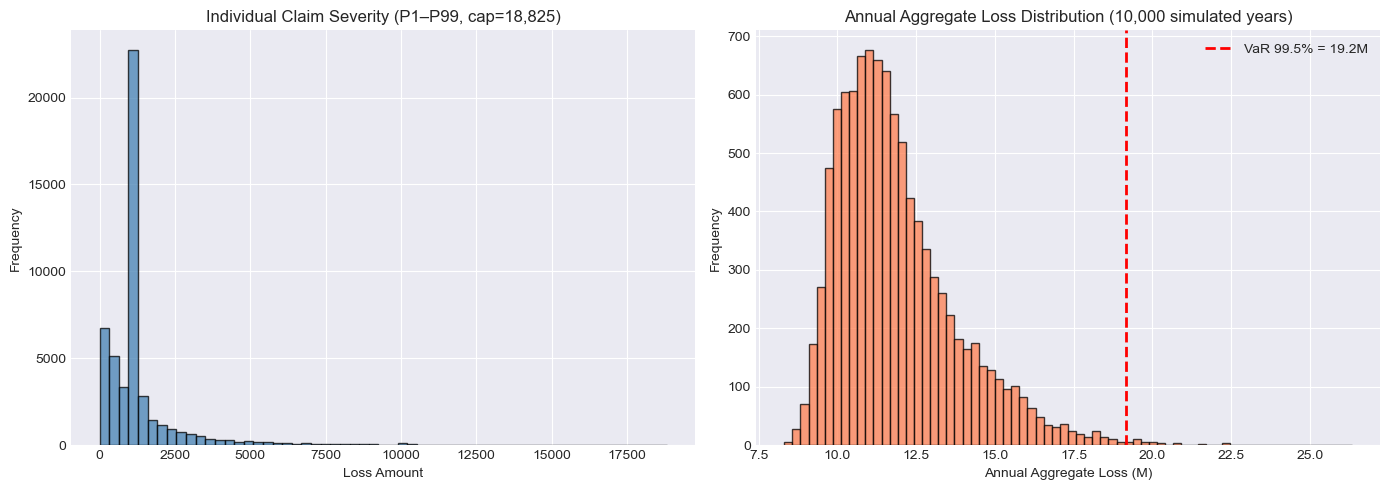

Annual loss distribution:
  P 50.0:   11,476,544.89
  P 90.0:   14,564,034.07
  P 99.0:   18,163,720.31
  P 99.5:   19,163,694.00
  P 99.9:   21,548,400.01


In [24]:
# Individual losses: cap at P99 to show meaningful shape
p99_indiv = np.percentile(individual_losses, 99)
bins_indiv = np.linspace(0, p99_indiv, 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    individual_losses[individual_losses <= p99_indiv],
    bins=bins_indiv, edgecolor='black', alpha=0.75, color='steelblue'
)
axes[0].set_xlabel('Loss Amount')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Individual Claim Severity (P1–P99, cap={p99_indiv:,.0f})')

# Annual losses: full range, well-behaved distribution
axes[1].hist(annual_losses / 1e6, bins=70, edgecolor='black', alpha=0.75, color='coral')
axes[1].axvline(
    np.percentile(annual_losses, 99.5) / 1e6,
    color='red', linestyle='--', linewidth=2,
    label=f'VaR 99.5% = {np.percentile(annual_losses,99.5)/1e6:.1f}M'
)
axes[1].set_xlabel('Annual Aggregate Loss (M)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Annual Aggregate Loss Distribution (10,000 simulated years)')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('../results/figures/12a_annual_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print('Annual loss distribution:')
for p in [50, 90, 99, 99.5, 99.9]:
    print(f'  P{p:5.1f}: {np.percentile(annual_losses, p):>15,.2f}')

## 3. Optimize the Program

In [25]:
optimizer = ReinsuanceOptimizer(
    individual_losses=individual_losses,
    annual_losses=annual_losses,
    cost_of_capital=0.08
)

optimal = optimizer.optimize_stop_loss()

Mean annual loss: 11,883,387
Attachment bounds: (11,883,387, 19,013,418)
Limit bounds:      (3,565,016, 11,883,387)

Optimizing Aggregate Stop Loss...
differential_evolution step 1: f(x)= 27555545.82987589
differential_evolution step 2: f(x)= 27551841.94799607
differential_evolution step 3: f(x)= 27551841.94799607
differential_evolution step 4: f(x)= 27549045.612740394
differential_evolution step 5: f(x)= 27549045.612740394
differential_evolution step 6: f(x)= 27549045.612740394
differential_evolution step 7: f(x)= 27549045.612740394
differential_evolution step 8: f(x)= 27548833.472499084
differential_evolution step 9: f(x)= 27548715.645348594
differential_evolution step 10: f(x)= 27548715.645348594
differential_evolution step 11: f(x)= 27548715.645348594
differential_evolution step 12: f(x)= 27548715.645348594
differential_evolution step 13: f(x)= 27548715.645348594
differential_evolution step 14: f(x)= 27548715.645348594
differential_evolution step 15: f(x)= 27548715.645348594
differ

In [26]:
print('\nOptimal Program Summary:')
print(f'  XL: {optimal["xl_limit"]/1e6:.1f}M xs {optimal["xl_retention"]/1e3:.0f}k')
print(f'  Stop Loss attachment: {optimal["sl_attachment"]:,.0f}  ({optimal["sl_attachment_ratio"]:.2f}x mean)')
print(f'  Stop Loss limit:      {optimal["sl_limit"]:,.0f}')
print(f'  VaR 99.5% before:     {optimal["var_99_5_original"]:,.2f}')
print(f'  VaR 99.5% after:      {optimal["var_99_5_retained"]:,.2f}')
pct = (optimal['var_99_5_original'] - optimal['var_99_5_retained']) / optimal['var_99_5_original'] * 100
print(f'  Capital relief:       {pct:.1f}%')


Optimal Program Summary:
  XL: 0.9M xs 50k
  Stop Loss attachment: 15,303,511  (1.29x mean)
  Stop Loss limit:      3,859,828
  VaR 99.5% before:     19,163,694.00
  VaR 99.5% after:      15,303,866.34
  Capital relief:       20.1%


## 4. Efficient Frontier

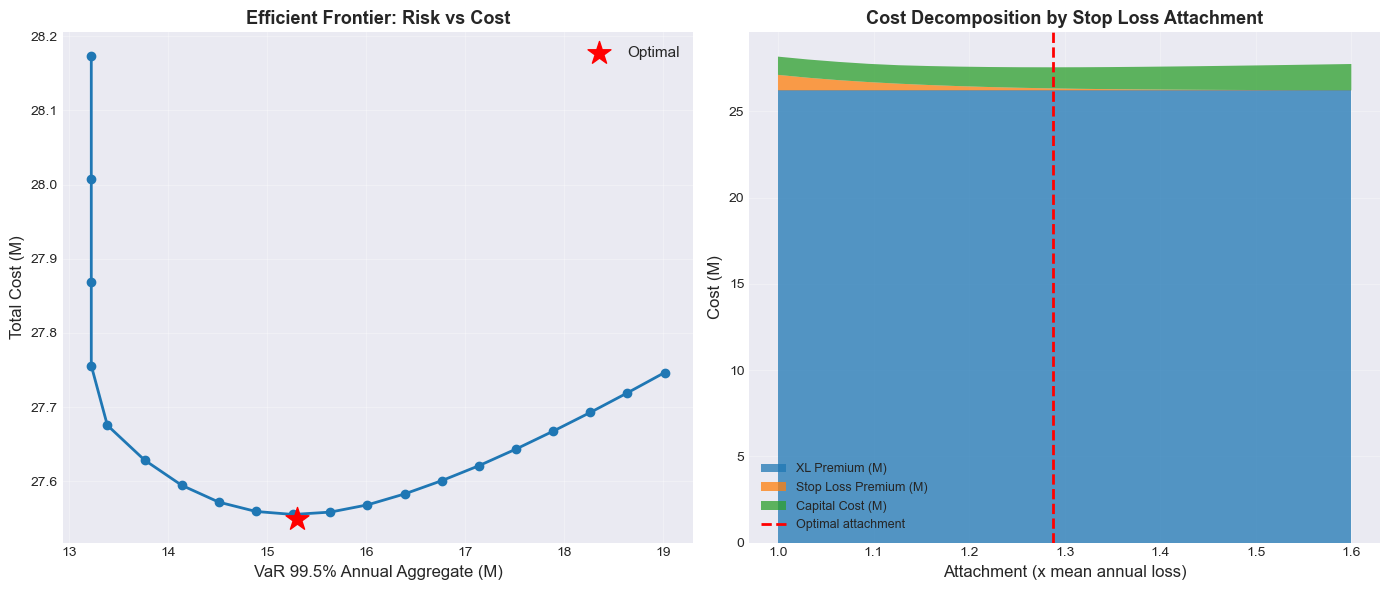

In [27]:
frontier = optimizer.efficient_frontier()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(frontier['var_99_5'] / 1e6, frontier['total_cost'] / 1e6,
             'o-', linewidth=2, markersize=6)
axes[0].scatter(
    optimal['var_99_5_retained'] / 1e6, optimal['total_cost'] / 1e6,
    s=300, c='red', marker='*', label='Optimal', zorder=5
)
axes[0].set_xlabel('VaR 99.5% Annual Aggregate (M)', fontsize=12)
axes[0].set_ylabel('Total Cost (M)', fontsize=12)
axes[0].set_title('Efficient Frontier: Risk vs Cost', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].stackplot(
    frontier['attachment_ratio'],
    frontier['xl_premium'] / 1e6,
    frontier['sl_premium'] / 1e6,
    frontier['capital_cost'] / 1e6,
    labels=['XL Premium (M)', 'Stop Loss Premium (M)', 'Capital Cost (M)'],
    alpha=0.75
)
axes[1].axvline(x=optimal['sl_attachment_ratio'], color='red',
                linestyle='--', linewidth=2, label='Optimal attachment')
axes[1].set_xlabel('Attachment (x mean annual loss)', fontsize=12)
axes[1].set_ylabel('Cost (M)', fontsize=12)
axes[1].set_title('Cost Decomposition by Stop Loss Attachment', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/12_efficient_frontier.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Annual Loss Distribution: Before vs After Program

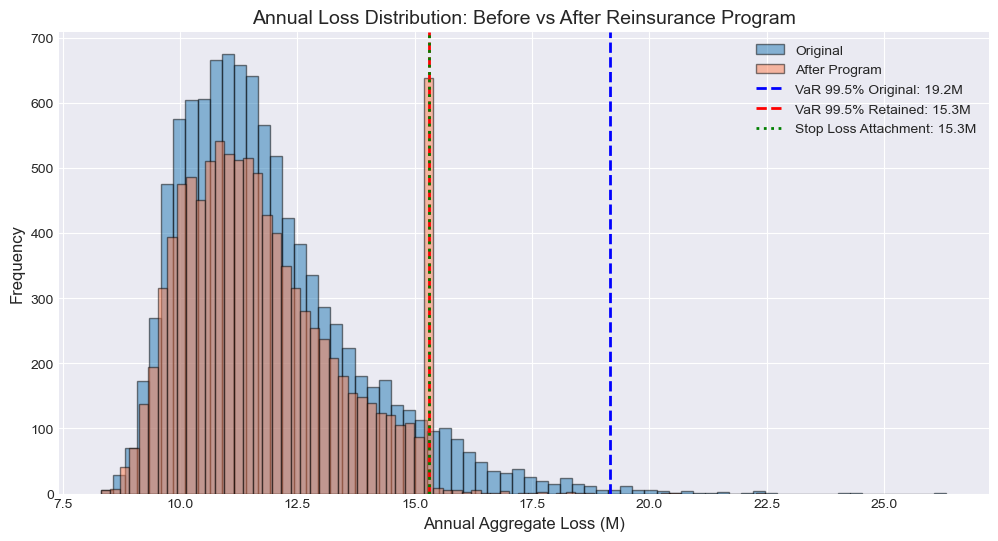

In [28]:
fig, ax = plt.subplots(figsize=(12, 6))

bins_annual = np.linspace(annual_losses.min(), annual_losses.max(), 70)

ax.hist(annual_losses / 1e6, bins=70, alpha=0.5,
        label='Original', edgecolor='black')
ax.hist(optimal['retained_annual'] / 1e6, bins=70, alpha=0.5,
        label='After Program', edgecolor='black', color='coral')

ax.axvline(optimal['var_99_5_original'] / 1e6, color='blue',
           linestyle='--', linewidth=2,
           label=f'VaR 99.5% Original: {optimal["var_99_5_original"]/1e6:.1f}M')
ax.axvline(optimal['var_99_5_retained'] / 1e6, color='red',
           linestyle='--', linewidth=2,
           label=f'VaR 99.5% Retained: {optimal["var_99_5_retained"]/1e6:.1f}M')
ax.axvline(optimal['sl_attachment'] / 1e6, color='green',
           linestyle=':', linewidth=2,
           label=f'Stop Loss Attachment: {optimal["sl_attachment"]/1e6:.1f}M')

ax.set_xlabel('Annual Aggregate Loss (M)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Annual Loss Distribution: Before vs After Reinsurance Program', fontsize=14)
ax.legend(fontsize=10)

plt.savefig('../results/figures/12b_annual_before_after.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Stress Testing

In [29]:
scenarios = create_stress_scenarios(annual_losses)
stress_results = stress_test_program(annual_losses, optimizer, scenarios)

cols = ['scenario', 'mean_annual_loss', 'var_99_5', 'var_99_5_retained', 'capital_relief_pct']
print(stress_results[cols].to_string(index=False))
stress_results.to_csv('../results/tables/stress_test_results.csv', index=False)

          scenario  mean_annual_loss     var_99_5  var_99_5_retained  capital_relief_pct
              base      1.188339e+07 1.916369e+07       1.530387e+07           20.141355
       catastrophe      1.241608e+07 6.529052e+07       6.143069e+07            5.911773
   frequency_shock      1.544667e+07 2.472289e+07       2.086307e+07           15.612362
severity_inflation      1.426006e+07 2.299643e+07       1.913661e+07           16.784463
    combined_shock      1.740043e+07 6.871450e+07       6.485467e+07            5.617195


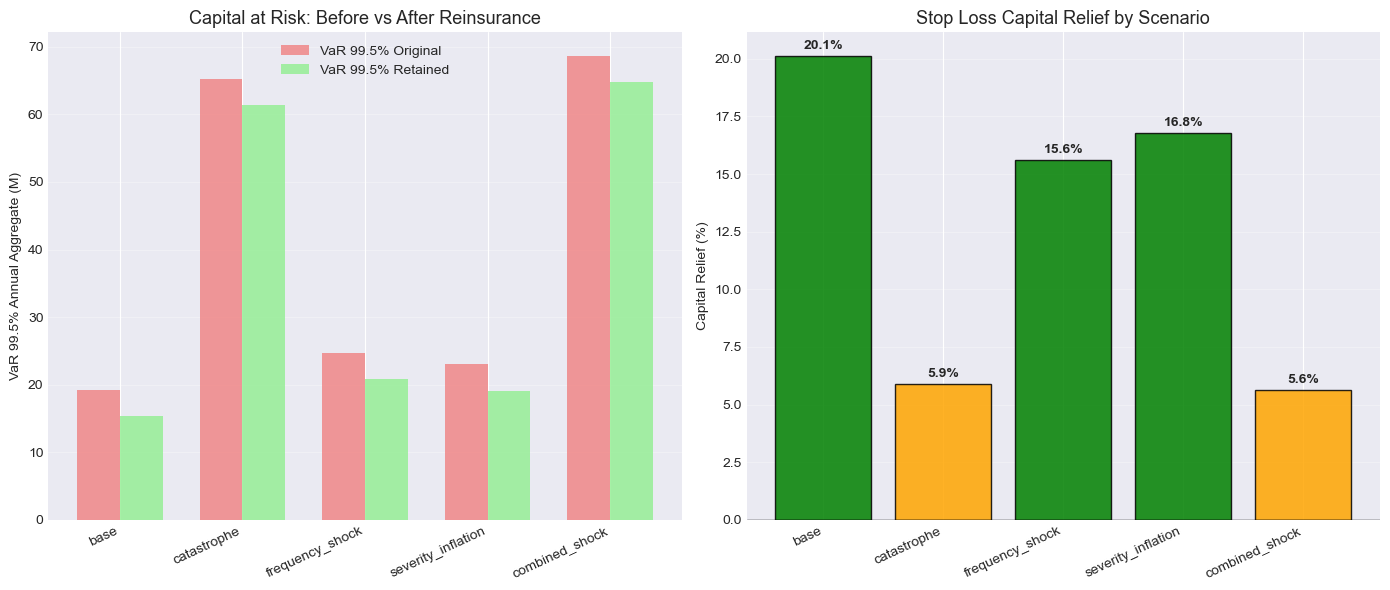

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

x = np.arange(len(stress_results))
w = 0.35

axes[0].bar(x - w/2, stress_results['var_99_5'] / 1e6, w,
            label='VaR 99.5% Original', alpha=0.8, color='lightcoral')
axes[0].bar(x + w/2, stress_results['var_99_5_retained'] / 1e6, w,
            label='VaR 99.5% Retained', alpha=0.8, color='lightgreen')
axes[0].set_xticks(x)
axes[0].set_xticklabels(stress_results['scenario'], rotation=25, ha='right')
axes[0].set_ylabel('VaR 99.5% Annual Aggregate (M)')
axes[0].set_title('Capital at Risk: Before vs After Reinsurance', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

colors = ['green' if v > 10 else 'orange' if v > 0 else 'red'
          for v in stress_results['capital_relief_pct']]
axes[1].bar(x, stress_results['capital_relief_pct'],
            color=colors, alpha=0.85, edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(stress_results['scenario'], rotation=25, ha='right')
axes[1].set_ylabel('Capital Relief (%)')
axes[1].set_title('Stop Loss Capital Relief by Scenario', fontsize=13)
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(stress_results['capital_relief_pct']):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/13_stress_test.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Final Summary

In [31]:
o = optimal
relief_pct = (o['var_99_5_original'] - o['var_99_5_retained']) / o['var_99_5_original'] * 100

print('=' * 65)
print('REINSURANCE PROGRAM SUMMARY')
print('=' * 65)
print(f'\nLayer 1 - Per-Occurrence XL (fixed):')
print(f'  Structure: {o["xl_limit"]/1e6:.0f}M xs {o["xl_retention"]/1e3:.0f}k')
print(f'  Premium:   {o["xl_premium"]:>15,.2f}')
print(f'\nLayer 2 - Aggregate Stop Loss (optimized):')
print(f'  Attachment:{o["sl_attachment"]:>15,.0f}  ({o["sl_attachment_ratio"]:.2f}x mean annual loss)')
print(f'  Limit:     {o["sl_limit"]:>15,.0f}')
print(f'  Premium:   {o["sl_premium"]:>15,.2f}')
print(f'\nCapital Relief (VaR 99.5% Annual Aggregate):')
print(f'  Before:    {o["var_99_5_original"]:>15,.2f}')
print(f'  After:     {o["var_99_5_retained"]:>15,.2f}')
print(f'  Relief:    {relief_pct:>14.1f}%')
print(f'\nTotal Program Cost:')
print(f'  XL Premium:         {o["xl_premium"]:>12,.2f}')
print(f'  Stop Loss Premium:  {o["sl_premium"]:>12,.2f}')
print(f'  Capital Cost (8%):  {o["capital_cost"]:>12,.2f}')
print(f'  Total:              {o["total_cost"]:>12,.2f}')
print('=' * 65)

REINSURANCE PROGRAM SUMMARY

Layer 1 - Per-Occurrence XL (fixed):
  Structure: 1M xs 50k
  Premium:     26,215,834.76

Layer 2 - Aggregate Stop Loss (optimized):
  Attachment:     15,303,511  (1.29x mean annual loss)
  Limit:           3,859,828
  Premium:        108,560.12

Capital Relief (VaR 99.5% Annual Aggregate):
  Before:      19,163,694.00
  After:       15,303,866.34
  Relief:              20.1%

Total Program Cost:
  XL Premium:         26,215,834.76
  Stop Loss Premium:    108,560.12
  Capital Cost (8%):  1,224,309.31
  Total:              27,548,704.18
